In [2]:
import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp
import matplotlib.pyplot as plt

from experiments.targets import Banana_t, MultivariateStudentT
from src.flows import RealNVP
from src.train import train

In [55]:
d = 10
df = 2
target = Banana_t(df=df, dim=d)

key = jax.random.key(0)
exact_samples = target.sample(seed=key, n=1000)

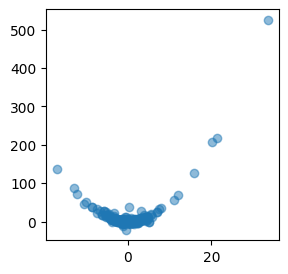

In [56]:
plt.figure(figsize=(3, 3))
plt.scatter(exact_samples[:, 0], exact_samples[:, 1], alpha=0.5)

In [57]:
ref_dist = MultivariateStudentT(df=df, dim=d)
key, subkey = jax.random.split(key)
n_train = 2000
ref_samples = ref_dist.sample(seed=subkey, sample_shape=(n_train, ))

In [58]:
model = RealNVP(dim=d, n_layers=4, hidden_dims=[d])
key, subkey = jax.random.split(key)
params = model.init(subkey, jnp.zeros((1, d)))

@jax.jit
def loss_fn(params):
    return model.apply(params, ref_samples, target.log_prob, method=model.reverse_kl)

learning_rate = 1e-3
max_iter = 3000
params_nvp, losses_nvp = train(loss_fn, params, learning_rate=learning_rate, max_iter=max_iter)

Running for 3,000 iterations: 100%|██████████| 3000/3000 [00:03<00:00, 791.52it/s]


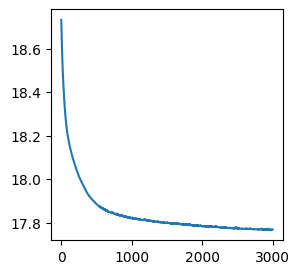

In [59]:
plt.figure(figsize=(3, 3))
plt.plot(losses_nvp)

In [60]:
key, subkey = jax.random.split(key)
test_samples = ref_dist.sample(seed=subkey, sample_shape=(1000, ))
transformed_samples, logdet = model.apply(params_nvp, test_samples, method=model.forward)

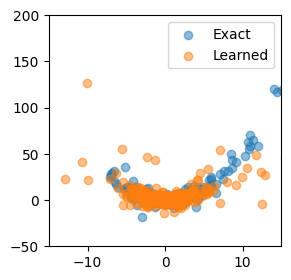

In [61]:
plt.figure(figsize=(3, 3))
plt.scatter(test_samples[:, 0], test_samples[:, 0]**2 * .5 + test_samples[:, 1], alpha=.5, label='Exact')
plt.scatter(transformed_samples[:, 0], transformed_samples[:, 1], alpha=0.5, label='Learned')
plt.ylim(-50, 200)
plt.xlim(-15, 15)
plt.legend()

In [62]:
logq = ref_dist.log_prob(test_samples) - logdet
logp = target.log_prob(transformed_samples)
log_weights = logp - logq
ess = jnp.exp(logsumexp(log_weights) * 2 - logsumexp(log_weights * 2))
print(f"ESS: {ess:.2f}")

ESS: 502.51


In [63]:
pullback_samples = model.apply(params_nvp, exact_samples, method=model.inverse)[0]

(-15.0, 15.0)

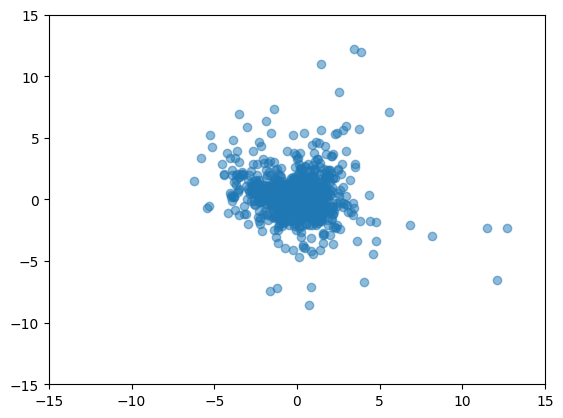

In [64]:
plt.scatter(pullback_samples[:, 0], pullback_samples[:, 1], alpha=0.5)
plt.xlim(-15, 15)
plt.ylim(-15, 15)

In [65]:
def plot_density_contour(logp, i, j, d, xlim=(-3, 3), ylim=(-3, 3), n_grid=100):
    x_vals = jnp.linspace(xlim[0], xlim[1], n_grid)
    y_vals = jnp.linspace(ylim[0], ylim[1], n_grid)
    X, Y = jnp.meshgrid(x_vals, y_vals, indexing='ij')
    points_2d = jnp.stack([X.ravel(), Y.ravel()], axis=-1)

    def embed_to_d(x_ij):
        x = jnp.zeros(d)
        x = x.at[i].set(x_ij[0])
        x = x.at[j].set(x_ij[1])
        return x

    logp_vmapped = jax.vmap(lambda x_ij: logp(embed_to_d(x_ij)))
    Z = jnp.exp(logp_vmapped(points_2d)).reshape((n_grid, n_grid))

    plt.contourf(x_vals, y_vals, Z.T, levels=15, cmap='viridis')
    plt.xlabel(f"x[{i}]")
    plt.ylabel(f"x[{j}]")
    plt.colorbar(label="Density")
    plt.title(f"Density contour in dimensions {i} and {j}")


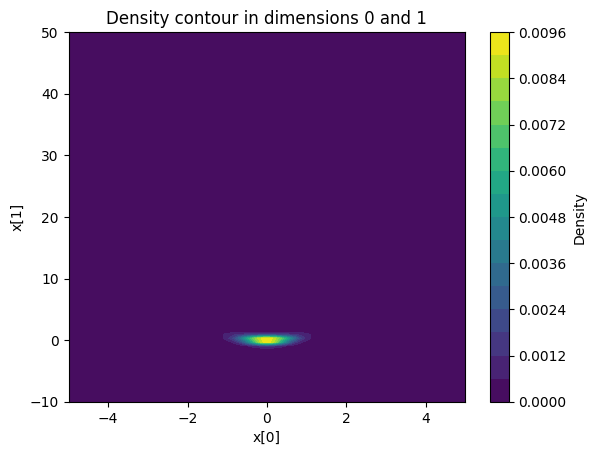

In [66]:
plot_density_contour(target.log_prob, 0, 1, d, xlim=(-5, 5), ylim=(-10, 50))

In [67]:
jnp.quantile(exact_samples[:, 1], jnp.array([0.025, 0.975]))

Array([-2.4773943, 21.944386 ], dtype=float32)

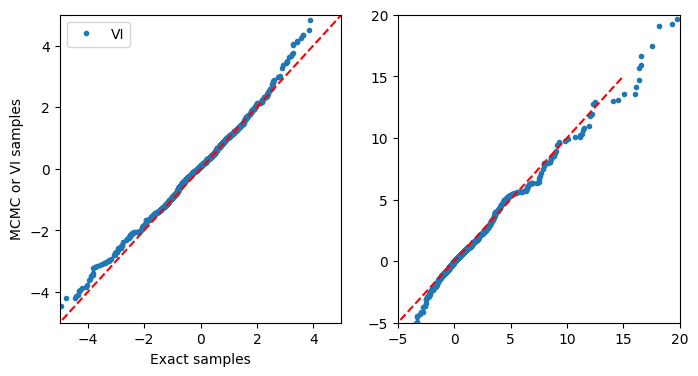

In [68]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for i, j in enumerate([0, 1]):
    exact_sorted = jnp.sort(exact_samples[:, j])
    vi_sorted = jnp.sort(transformed_samples[:, j])
    ax[i].plot(exact_sorted, vi_sorted, '.', label='VI')
    ax[i].plot([-15, 15], [-15, 15], 'r--')  # Reference line for y=x

ax[0].set_xlim(-5., 5)
ax[0].set_ylim(-5., 5)
ax[1].set_xlim(-5, 20)
ax[1].set_ylim(-5, 20)
ax[0].set_xlabel('Exact samples')
ax[0].set_ylabel('MCMC or VI samples')
ax[0].legend()